# 01 - Data Exploration

**AI Career & Skill Recommendation System**

This notebook explores `backend/data/career_dataset.csv`, the dataset used to train the career-prediction model.

> **Note on the data:** This is a **synthetic/demo dataset**, generated by `training/generate_dataset.py`. It was built so that features (skills, interests, experience) correlate realistically with career labels, based on a transparent, documented skill profile for each career (see `backend/app/career_profiles.py`). It is **not** scraped real-world resume data. This is stated clearly so the ML workflow can be explained honestly.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

DATA_PATH = os.path.join('..', 'backend', 'data', 'career_dataset.csv')
df = pd.read_csv(DATA_PATH)
df.head()

,education_level,field_of_study,years_experience,preferred_work_type,python_level,javascript_level,java_level,sql_level,react_level,nodejs_level,...,cybersecurity_level,statistics_level,communication_level,problem_solving_level,interest_ai,interest_web,interest_data,interest_cloud,interest_security,career
0,Master,Computer Science,6.0,Remote,3,0,2,3,0,2,...,1,0,0,3,1,3,3,0,0,Backend Developer
1,Intermediate/High School,Information Technology,0.5,Hybrid,2,1,2,3,0,2,...,0,0,1,2,0,3,3,2,1,Backend Developer
2,Master,Computer Science,7.0,Remote,1,0,1,2,0,0,...,3,0,2,2,1,1,0,0,2,Cybersecurity Analyst
3,Master,Computer Science,3.4,On-site,2,0,0,2,0,0,...,1,0,0,3,1,2,2,3,3,DevOps Engineer
4,Bachelor,Other,0.3,Remote,3,0,0,2,1,0,...,2,0,0,3,1,2,1,3,3,DevOps Engineer


## Shape and columns

In [2]:
print('Shape:', df.shape)
print('\nColumns:')
print(list(df.columns))

Shape: (2200, 23)

Columns:
['education_level', 'field_of_study', 'years_experience', 'preferred_work_type', 'python_level', 'javascript_level', 'java_level', 'sql_level', 'react_level', 'nodejs_level', 'machine_learning_level', 'data_analysis_level', 'cloud_level', 'cybersecurity_level', 'statistics_level', 'communication_level', 'problem_solving_level', 'interest_ai', 'interest_web', 'interest_data', 'interest_cloud', 'interest_security', 'career']


## Data types

In [3]:
df.dtypes

education_level               str
field_of_study                str
years_experience          float64
preferred_work_type           str
python_level                int64
javascript_level            int64
java_level                  int64
sql_level                   int64
react_level                 int64
nodejs_level                int64
machine_learning_level      int64
data_analysis_level         int64
cloud_level                 int64
cybersecurity_level         int64
statistics_level            int64
communication_level         int64
problem_solving_level       int64
interest_ai                 int64
interest_web                int64
interest_data               int64
interest_cloud              int64
interest_security           int64
career                        str
dtype: object

## Missing values

In [4]:
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found.')

No missing values found.


## Duplicate rows

In [5]:
n_dupes = df.duplicated().sum()
print(f'Duplicate rows: {n_dupes}')

Duplicate rows: 0


## Basic statistics (numeric columns)

In [6]:
df.describe()

,years_experience,python_level,javascript_level,java_level,sql_level,react_level,nodejs_level,machine_learning_level,data_analysis_level,cloud_level,cybersecurity_level,statistics_level,communication_level,problem_solving_level,interest_ai,interest_web,interest_data,interest_cloud,interest_security
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,2.495727,1.718636,0.711364,0.400000,1.727727,0.650455,0.567273,0.884091,1.064091,0.881818,0.755909,1.031364,0.950000,1.787727,1.515455,1.524545,1.855909,1.367273,1.378182
std,2.494243,1.146566,1.102256,0.731914,1.032864,1.015612,0.902738,1.166347,1.201023,1.168262,1.031986,1.158404,1.082857,1.105172,1.068690,1.074038,1.091812,1.023428,1.042820
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.700000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,1.700000,2.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,2.000000,1.000000,1.000000,2.000000,1.000000,1.000000
75%,3.500000,3.000000,1.000000,1.000000,3.000000,1.000000,1.000000,2.000000,2.000000,2.000000,1.000000,2.000000,2.000000,3.000000,2.000000,2.000000,3.000000,2.000000,2.000000
max,15.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000


## Target class distribution

Checking for class imbalance before training.

career
Backend Developer            220
Cybersecurity Analyst        220
DevOps Engineer              220
Frontend Developer           220
Data Scientist               220
Data Analyst                 220
Full Stack Developer         220
Cloud Engineer               220
AI Engineer                  220
Machine Learning Engineer    220
Name: count, dtype: int64


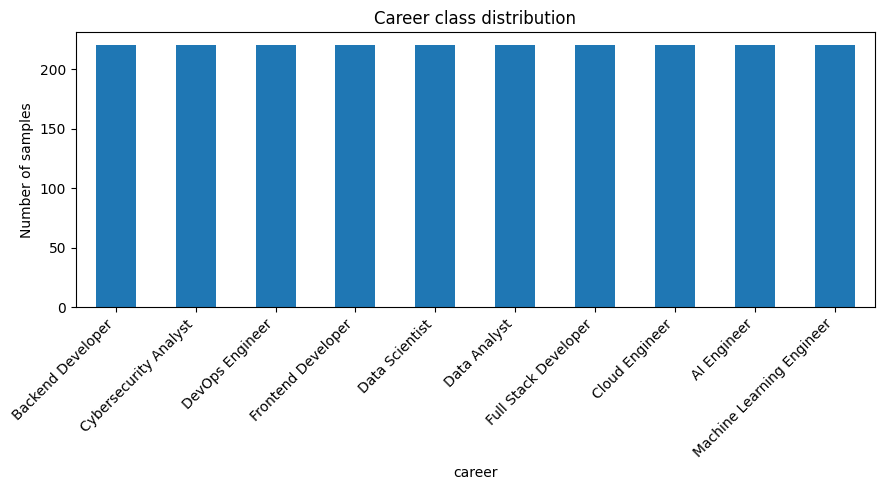

In [7]:
class_counts = df['career'].value_counts()
print(class_counts)

plt.figure(figsize=(9, 5))
class_counts.plot(kind='bar')
plt.title('Career class distribution')
plt.ylabel('Number of samples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Categorical feature distributions

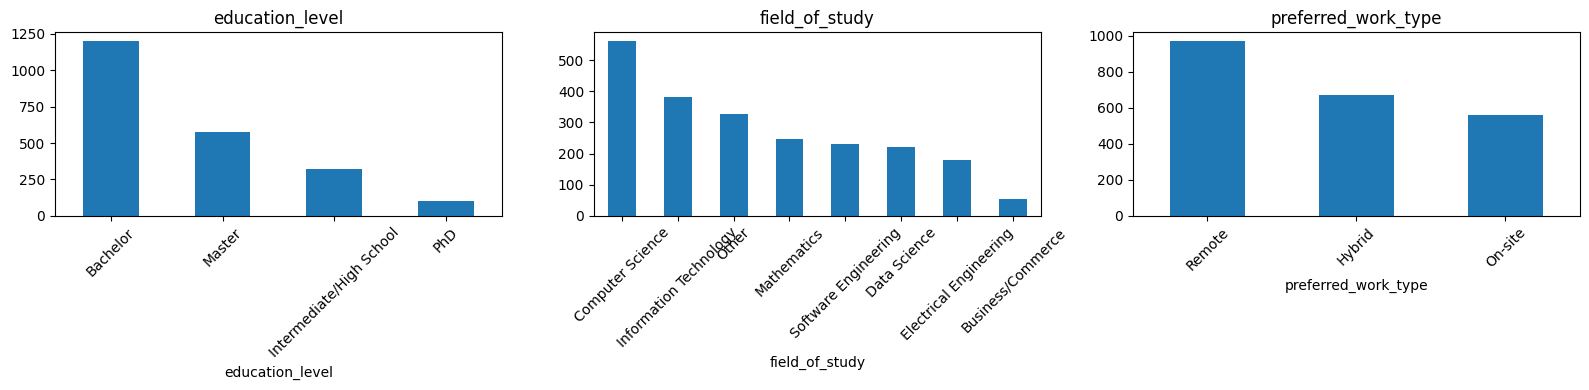

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['education_level', 'field_of_study', 'preferred_work_type']):
    df[col].value_counts().plot(kind='bar', ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## Skill level distributions (sample)

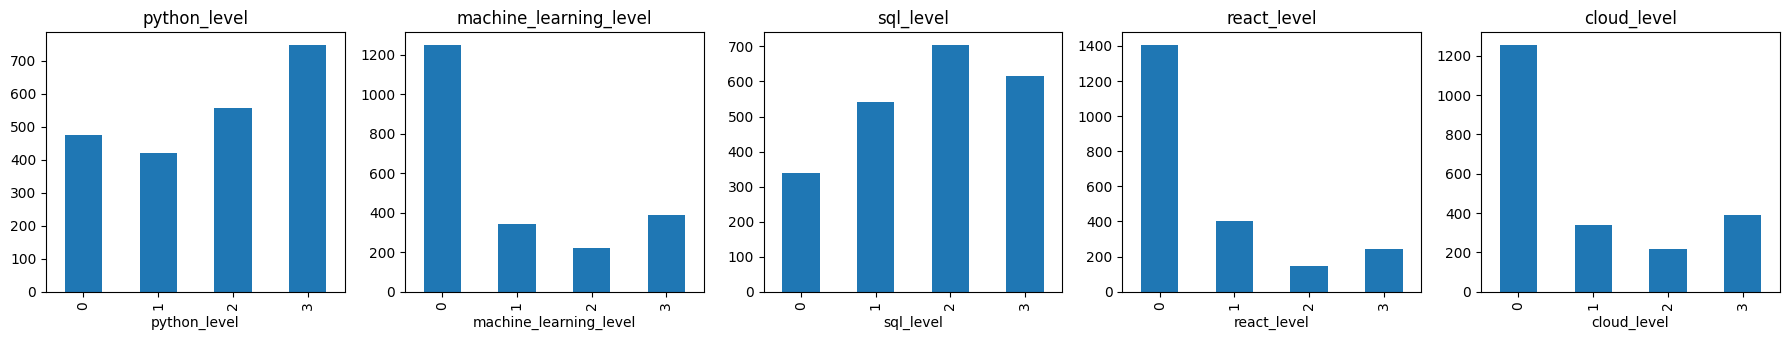

In [9]:
skill_cols = ['python_level', 'machine_learning_level', 'sql_level', 'react_level', 'cloud_level']
fig, axes = plt.subplots(1, len(skill_cols), figsize=(18, 3.5))
for ax, col in zip(axes, skill_cols):
    df[col].value_counts().sort_index().plot(kind='bar', ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## Correlation between numeric skill levels

A quick sanity check: careers with overlapping skill needs (e.g. AI Engineer and Machine Learning Engineer) should show correlated skill patterns.

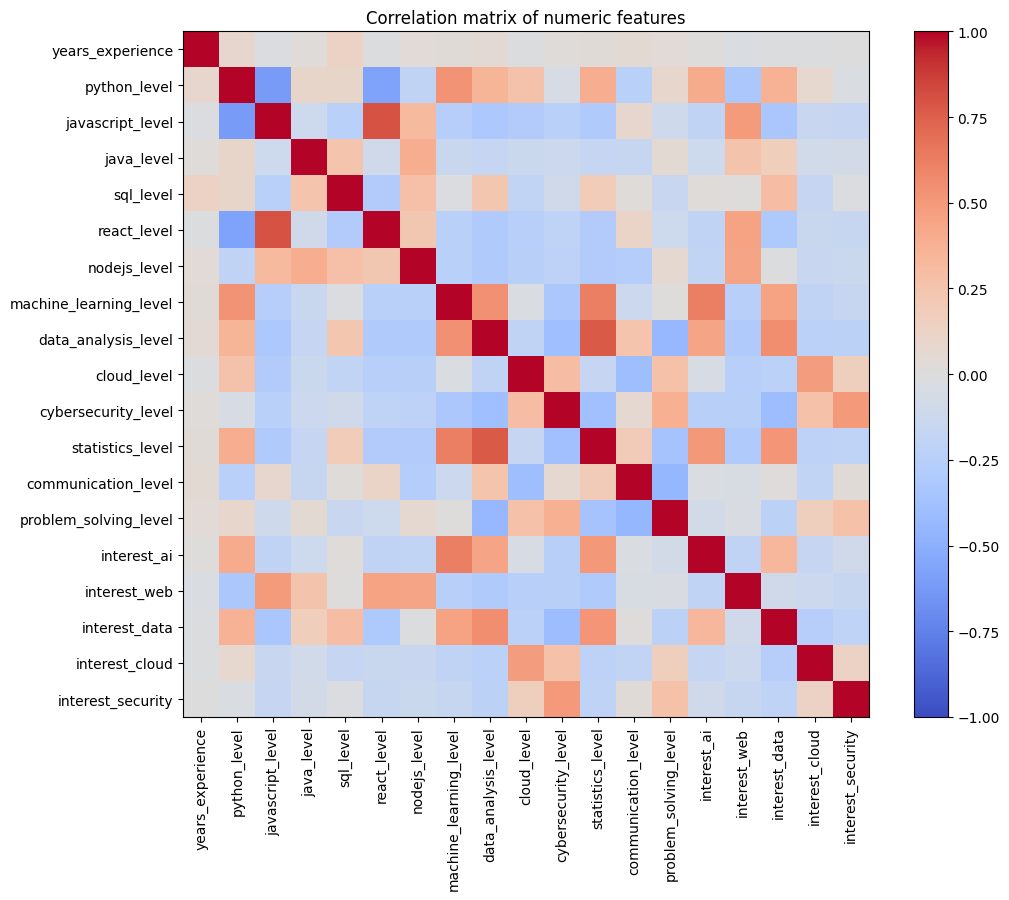

In [10]:
numeric_cols = [c for c in df.columns if df[c].dtype in ['int64', 'float64']]
corr = df[numeric_cols].corr()
plt.figure(figsize=(11, 9))
im = plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im)
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=90)
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.title('Correlation matrix of numeric features')
plt.tight_layout()
plt.show()

## Summary of findings

- No missing values or duplicate rows were introduced by the generator.
- Classes are balanced (220 samples per career, 2200 rows total).
- Skill levels show the expected pattern: skills relevant to a career cluster higher for samples labeled with that career.
- Next step: `02_data_preprocessing.ipynb` builds the preprocessing pipeline.